# Imports

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
file_path = '../data/raw_sweeps' # add path to data 

In [3]:
from sweep import sweep_load as sl
from sweep import raster
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
from cycler import cycler
%matplotlib inline
from matplotlib.colors import Normalize
import matplotlib.image as mpimg

from matplotlib import cm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import LogLocator, SymmetricalLogLocator
import matplotlib.patches as mpatches
from matplotlib.path import Path
from scipy.interpolate import splprep, splev
import h5py
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
from matplotlib.lines import Line2D

import sys
sys.path.append("../utils")
from utils import *

In [4]:
scale = 0.56
plt.rcParams.update({
    # Font and font sizes
    'font.family': 'sans-serif',
    'axes.labelsize': 8, 
    'axes.titlesize': 8,
    'font.size': 9,
    'legend.title_fontsize': 7,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,

    # Ticks
    'xtick.direction': 'in',
    'xtick.top': 'True',
    'ytick.direction': 'in',
    'ytick.right': 'True',

    'xtick.major.size': 5*scale,
    'xtick.major.width': 1.5*scale,
    'xtick.minor.size': 2.5*scale,
    'xtick.minor.width': 1.5*scale,

    'ytick.major.size': 5*scale,
    'ytick.major.width': 1.5*scale,
    'ytick.minor.size': 2.5*scale,
    'ytick.minor.width': 1.5*scale,


    # Linewidths
    'axes.linewidth': 1.5*scale,
    'lines.linewidth': 2.5*scale,
})


# High field Landau fan 

In [10]:
def plot_landau_fan(fig, ax, norm, cmap="viridis", files=[1960]):
    for file in files:
        contact = 1 # choose which contact pair to plot = 1,2,3  
        data = sl.pload(file_path, file)
        md = sl.load_meta(file_path, file)
        ys = data['ys'][0]
        print(ys.max())
        zs = data[f'sr830_{contact}_X']/data['sr830_4_X']
        
        Vtgs = data['xs'][0]
        Vbgs = data['xs'][1]
        xs, D_vec = calculate_n_D(Vtgs, Vbgs, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
        print("D", D_vec[0])
        plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True)
        ax.set_ylim(0, 12)
    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylabel(r'$B$ (T)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    return plot


## D = 1

5.0
D 0.9951133459733648
12.0
D 0.9950728019081713


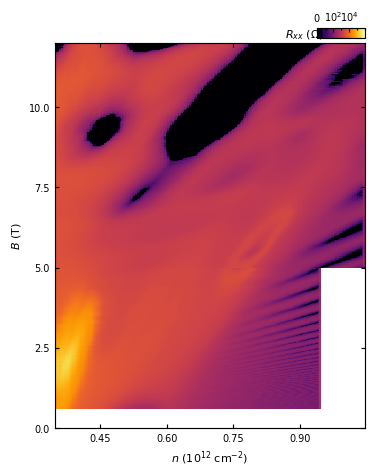

In [11]:
fig = plt.figure(figsize=(4,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E6)
plot = plot_landau_fan(fig, ax, norm, "inferno", [1840, 1959])

pos = ax.get_position()
cb_width = 0.12  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-20, x=-0.25)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

## D = 0.95

12.0
D 0.9453576786746966


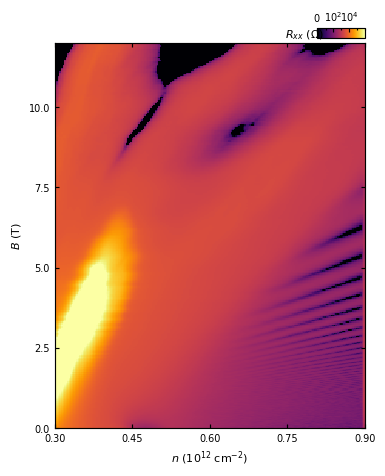

In [12]:

fig = plt.figure(figsize=(4,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E6)
plot = plot_landau_fan(fig, ax, norm, "inferno", [1960])

pos = ax.get_position()
cb_width = 0.12  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-20, x=-0.25)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

# Full figure


5.0
D 0.9951133459733648
12.0
D 0.9950728019081713
12.0
D 0.9453576786746966


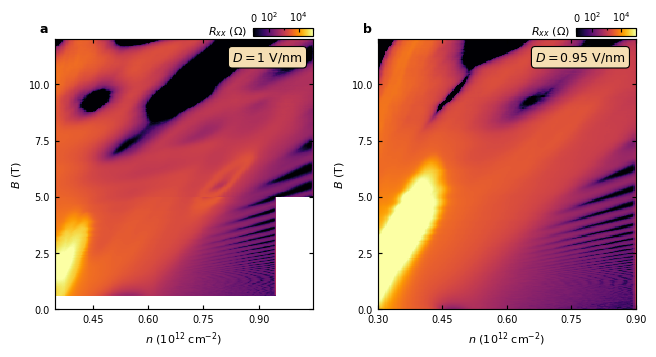

In [15]:
# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(7.5, 3.5))
gs = GridSpec(1, 2, figure=fig,   
                       width_ratios=[1, 1],
                       height_ratios=[1],
                       hspace=0.4, wspace=0.25)

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

################ Panel a ##################
ax = fig.add_subplot(gs[0, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + 1*label_spacer, "a", fontweight='bold')

norm = colors.SymLogNorm(linthresh=100, vmin=0, vmax=1E5)
plot = plot_landau_fan(fig, ax, norm, "inferno", [1840, 1959])
ax.text(0.96, 0.96, r'$D = 1$ V/nm', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.annotate(r'$R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  

################ Panel b ##################
ax = fig.add_subplot(gs[0, 1])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + 1*label_spacer, "b", fontweight='bold')

plot = plot_landau_fan(fig, ax, norm, "inferno", [1960])
ax.text(0.96, 0.96, r'$D = 0.95$ V/nm', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='k',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                  edgecolor='k', linewidth=0.8, alpha=1))

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.annotate(r'$R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  

plt.show()
fig.savefig("si-fig-high-field-fans.pdf", dpi=300, bbox_inches='tight',
            pad_inches=0.02, transparent=False)